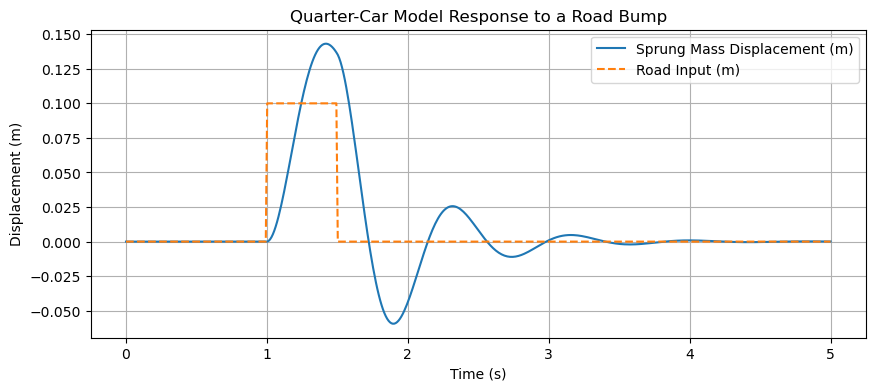

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# 1. Define the model
def quarter_car_model(t, y, m, c, k, road_input):
    x, x_dot = y
    z_road = road_input(t)
    x_ddot = (-c * x_dot - k * (x - z_road)) / m
    return [x_dot, x_ddot]

# 2. Parameters and Inputs
m, c, k = 250.0, 1000.0, 15000.0
def road_bump(t):
    # A 10cm bump between t=1.0 and t=1.5
    return 0.1 if 1.0 < t < 1.5 else 0.0

# 3. Solve the ODE
t_span = (0, 5)
t_eval = np.linspace(0, 5, 500)
sol = solve_ivp(
    lambda t, y: quarter_car_model(t, y, m, c, k, road_bump), 
    t_span, [0.0, 0.0], t_eval=t_eval
)

# 4. Plot results
plt.figure(figsize=(10, 4))
plt.plot(sol.t, sol.y[0], label='Sprung Mass Displacement (m)')
plt.plot(sol.t, [road_bump(t) for t in sol.t], '--', label='Road Input (m)')
plt.title("Quarter-Car Model Response to a Road Bump")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid(True)
plt.show()

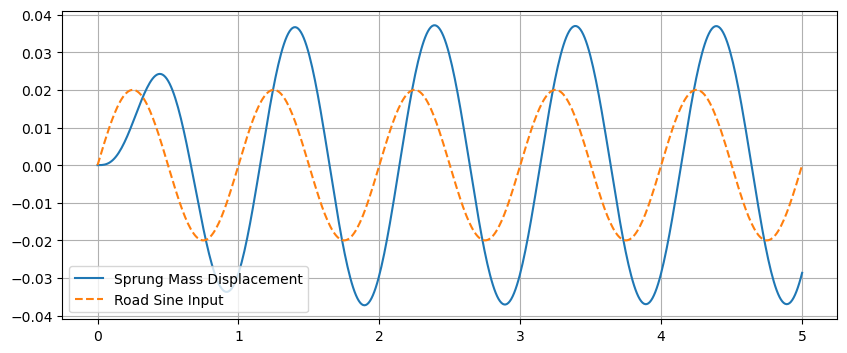

In [2]:
# Assuming your quarter_car_model is already defined as before

# 1. Define your road profiles
def bump_profile(t):
    return 0.05 if 1 <= t <= 1.2 else 0.0

def sine_wave_profile(t):
    return 0.02 * np.sin(2 * np.pi * 1 * t)

# 2. Example: Using the sine wave profile
t_span = (0, 5)
t_eval = np.linspace(0, 5, 500)

# Pass the function name directly
sol = solve_ivp(
    lambda t, y: quarter_car_model(t, y, m, c, k, sine_wave_profile), 
    t_span, [0.0, 0.0], t_eval=t_eval
)

# 3. Plotting
plt.figure(figsize=(10, 4))
plt.plot(sol.t, sol.y[0], label='Sprung Mass Displacement')
plt.plot(sol.t, [sine_wave_profile(t) for t in sol.t], '--', label='Road Sine Input')
plt.legend(); plt.grid(True); plt.show()

In [5]:
import os
print("Current Working Directory:", os.getcwd())
import sys
print("Python Path:", sys.path)

Current Working Directory: C:\Users\ASUS
Python Path: ['C:\\Users\\ASUS', 'C:\\Users\\ASUS\\anaconda3\\python311.zip', 'C:\\Users\\ASUS\\anaconda3\\DLLs', 'C:\\Users\\ASUS\\anaconda3\\Lib', 'C:\\Users\\ASUS\\anaconda3', '', 'C:\\Users\\ASUS\\anaconda3\\Lib\\site-packages', 'C:\\Users\\ASUS\\anaconda3\\Lib\\site-packages\\win32', 'C:\\Users\\ASUS\\anaconda3\\Lib\\site-packages\\win32\\lib', 'C:\\Users\\ASUS\\anaconda3\\Lib\\site-packages\\Pythonwin']


In [7]:
# --- Cell 1: Define Models ---
import numpy as np

def quarter_car_model(t, y, m, c, k, road_input):
    x, x_dot = y
    z_road = road_input(t)
    x_ddot = (-c * x_dot - k * (x - z_road)) / m
    return [x_dot, x_ddot]

def bump_profile(t):
    return 0.05 if 1 <= t <= 1.2 else 0.0

# --- Cell 2: Run Simulation ---
# Now you can remove the "from ... import ..." lines 
# and your script will run without looking for external files.

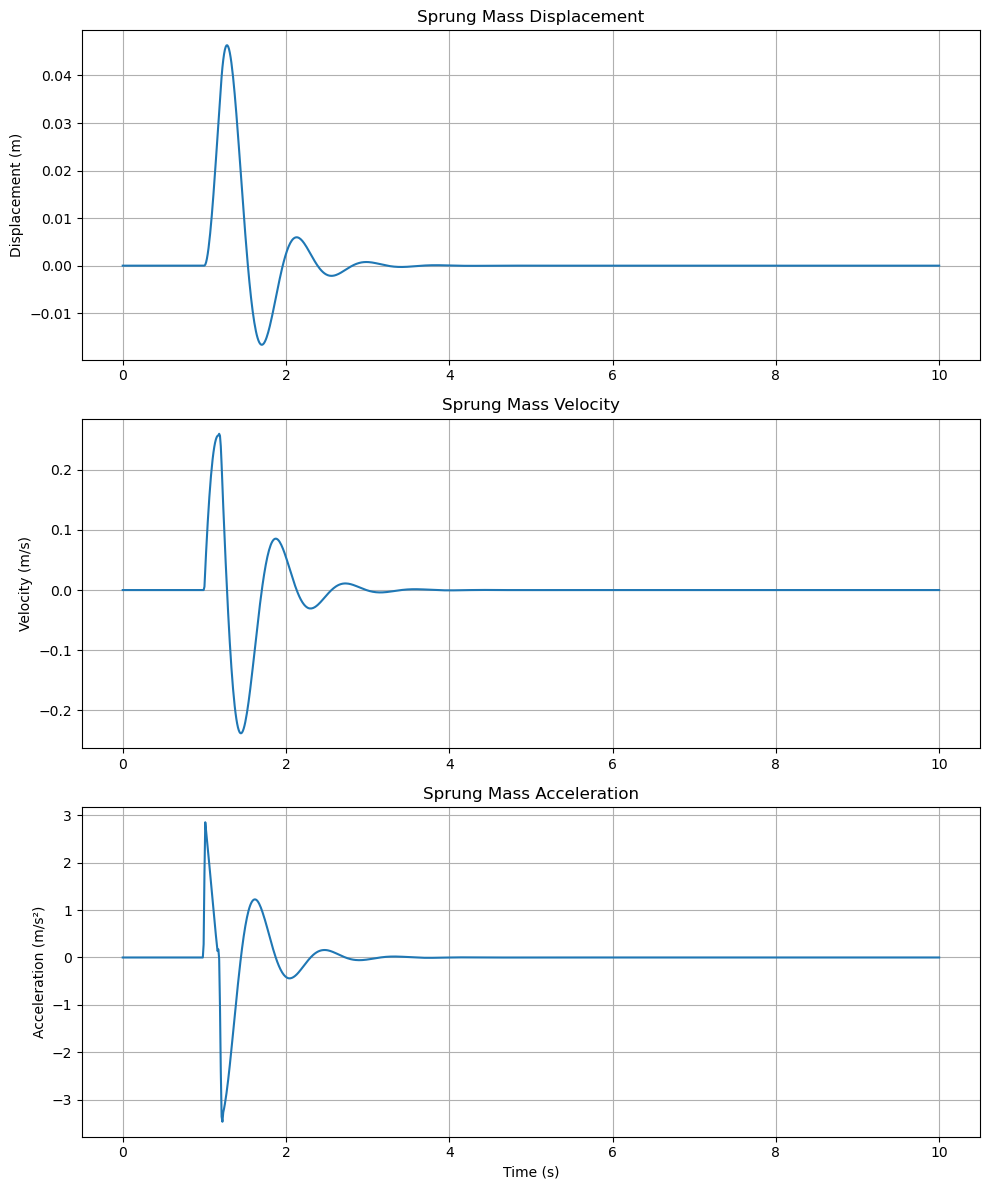

Simulation completed successfully. Files saved to /plots and /results folders.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.integrate import solve_ivp

# --- 1. Define Model and Profiles (Previously in separate files) ---
def quarter_car_model(t, y, m, c, k, road_input):
    x, x_dot = y
    z_road = road_input(t)
    # Equation of Motion for SDOF system
    x_ddot = (-c * x_dot - k * (x - z_road)) / m
    return [x_dot, x_ddot]

def bump_profile(t):
    return 0.05 if 1 <= t <= 1.2 else 0.0

# --- 2. Setup Directories ---
# Ensuring output folders exist to prevent errors during plt.savefig or np.savetxt
os.makedirs("plots", exist_ok=True)
os.makedirs("results", exist_ok=True)

# --- 3. Vehicle Parameters ---
m, c, k = 250.0, 1200.0, 15000.0

# --- 4. Simulation Time & Initial Conditions ---
t_span = (0, 10)
t_eval = np.linspace(0, 10, 1000)
y0 = [0.0, 0.0]

# --- 5. Solve ODE ---
solution = solve_ivp(
    lambda t, y: quarter_car_model(t, y, m, c, k, bump_profile),
    t_span, y0, t_eval=t_eval
)

# --- 6. Extract and Process Results ---
time = solution.t
displacement = solution.y[0]
velocity = solution.y[1]
acceleration = np.gradient(velocity, time)

# --- 7. Plotting ---
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

axes[0].plot(time, displacement)
axes[0].set(title="Sprung Mass Displacement", ylabel="Displacement (m)")
axes[0].grid(True)

axes[1].plot(time, velocity)
axes[1].set(title="Sprung Mass Velocity", ylabel="Velocity (m/s)")
axes[1].grid(True)

axes[2].plot(time, acceleration)
axes[2].set(title="Sprung Mass Acceleration", ylabel="Acceleration (m/s²)", xlabel="Time (s)")
axes[2].grid(True)

plt.tight_layout()
plt.savefig("plots/simulation_results.png")
plt.show()

# --- 8. Save Data ---
data = np.column_stack((time, displacement, velocity, acceleration))
np.savetxt(
    "results/simulation_data.csv",
    data,
    delimiter=",",
    header="time,displacement,velocity,acceleration",
    comments=""
)

print("Simulation completed successfully. Files saved to /plots and /results folders.")